# 01 Dataset Audit

This notebook performs the initial audit of the Genius Kitchen dataset before formal preprocessing.

## Objectives
- inspect all columns
- confirm row counts
- check null values
- inspect duplicates
- inspect rating distribution
- inspect date range
- inspect join coverage between interactions and recipes

This notebook is the exploratory version and will later be formalised into `src/data/dataset_audit.py`.

In [27]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 200)

# Make project root importable when running from notebooks/
PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.paths import (
    RAW_INTERACTIONS_PATH,
    RAW_RECIPES_PATH,
    PP_RECIPES_PATH,
    OUTPUTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    LOGS_DIR,
)

In [28]:
for folder in [OUTPUTS_DIR, TABLES_DIR, FIGURES_DIR, LOGS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output directories are ready.")

Output directories are ready.


## 1. Load datasets

Load the three main files required for the audit:
- `RAW_interactions.csv`
- `RAW_recipes.csv`
- `PP_recipes.csv`

In [29]:
interactions = pd.read_csv(RAW_INTERACTIONS_PATH)
raw_recipes = pd.read_csv(RAW_RECIPES_PATH)
pp_recipes = pd.read_csv(PP_RECIPES_PATH)

print("Interactions shape:", interactions.shape)
print("Raw recipes shape:", raw_recipes.shape)
print("PP recipes shape:", pp_recipes.shape)

Interactions shape: (1132367, 5)
Raw recipes shape: (231637, 12)
PP recipes shape: (178265, 8)


In [30]:
display(interactions.head(3))
display(raw_recipes.head(3))
display(pp_recipes.head(3))

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for 15 minutes.Added a shake of cayenne and a pinch of salt. Used low fat sour cream. Thanks.
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall evening. Should have doubled it ;)<br/><br/>Second time around, forgot the remaining cumin. We usually love cumin, but didn't notice the missing 1/2 ..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not quite a whole package (10oz) of white chips. Great!


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'north-american', 'side-dishes', 'vegetables', 'mexican', 'easy', 'fall', 'holiday-event',...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'depending on size of squash , cut into half or fourths', 'remove seeds', 'for spicy squash , drizzle olive oil or melted butter over each cut squash piec...","autumn is my favorite time of year to cook! this recipe \r\ncan be prepared either spicy or sweet, your choice!\r\ntwo of my posted mexican-inspired seasoning mix recipes are offered as suggestions.","['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter', 'olive oil', 'salt']",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'north-american', 'breakfast', 'main-dish', 'pork', 'american', 'oven', 'easy', 'kid-frien...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough into the bottom and sides of a 12 inch pizza pan', 'bake for 5 minutes until set but not browned', 'cut sausage into small pieces', 'whisk eggs and m...",this recipe calls for the crust to be prebaked a bit before adding ingredients. feel free to change sausage to ham or bacon. this warms well in the microwave for those late risers.,"['prepared pizza crust', 'sausage patty', 'eggs', 'milk', 'salt and pepper', 'cheese']",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'main-dish', 'chili', 'crock-pot-slow-cooker', 'dietary', 'equipment', '4-hours-or-less']","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add chopped onions to ground beef when almost brown and sautee until wilted', 'add all other ingredients', 'add kidney beans if you like beans in your chili', '...",this modified version of 'mom's' chili was a hit at our 2004 christmas party. we made an extra large pot to have some left to freeze but it never made it to the freezer. it was a favorite by all. ...,"['ground beef', 'yellow onions', 'diced tomatoes', 'tomato paste', 'tomato soup', 'rotel tomatoes', 'kidney beans', 'water', 'chili powder', 'ground cumin', 'salt', 'lettuce', 'cheddar cheese']",13


,id,i,name_tokens,ingredient_tokens,steps_tokens,techniques,calorie_level,ingredient_ids
0,424415,23,"[40480, 37229, 2911, 1019, 249, 6878, 6878, 2839, 1781, 40481]","[[2911, 1019, 249, 6878], [1353], [6953], [15341, 3261], [2056, 857, 643, 1631, 20480]]","[40480, 40482, 21662, 481, 6878, 500, 246, 1614, 1911, 10757, 240, 674, 9933, 8400, 40478, 40482, 1082, 589, 16126, 500, 481, 6878, 2839, 1781, 5024, 240, 488, 13770, 485, 23667, 40478, 40482, 123...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",0,"[389, 7655, 6270, 1527, 3406]"
1,146223,96900,"[40480, 18376, 7056, 246, 1531, 2032, 40481]","[[17918], [25916], [2507, 6444], [8467, 1179], [8780], [6812], [4370, 2653, 18376], [2654, 5581, 34904, 5940], [15341], [10848], [21447, 7869], [6953]]","[40480, 40482, 729, 2525, 10906, 485, 43, 8393, 40478, 40482, 23667, 17918, 240, 25916, 240, 2507, 6444, 488, 8467, 1179, 40478, 40482, 4846, 6737, 8780, 488, 7087, 862, 40478, 40482, 3336, 666, 4...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]",0,"[2683, 4969, 800, 5298, 840, 2499, 6632, 7022, 1511, 3248, 4964, 6270]"
2,312329,120056,"[40480, 21044, 16954, 8294, 556, 10837, 40481]","[[5867, 24176], [1353], [6953], [1301, 11332], [21453, 8361], [25845, 8111, 11332], [23488, 8361], [37754, 10734], [652, 25, 3035, 11959, 10734], [10837], [19811, 21137, 556, 20323, 15022, 296, 7,...","[40480, 40482, 8240, 481, 24176, 296, 1353, 666, 246, 1719, 5082, 40478, 40482, 4846, 481, 21298, 240, 37754, 10734, 240, 652, 25, 3035, 11959, 240, 296, 10837, 485, 481, 5082, 674, 2030, 485, 246...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,"[1257, 7655, 6270, 590, 5024, 1119, 4883, 6696, 7946, 5648, 7239, 7705, 7594, 1168, 2683]"


## 2. Inspect all columns

This section checks:
- column names
- data types
- non-null counts
- unique values
- sample values

In [31]:
def column_summary(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        non_null = df[col].notna().sum()
        null_count = df[col].isna().sum()
        unique_count = df[col].nunique(dropna=True)
        sample_series = df[col].dropna()
        sample_value = None if sample_series.empty else str(sample_series.iloc[0])[:150]

        rows.append({
            "dataset": dataset_name,
            "column": col,
            "dtype": str(df[col].dtype),
            "non_null_count": int(non_null),
            "null_count": int(null_count),
            "null_percentage": round((null_count / len(df)) * 100, 4),
            "n_unique": int(unique_count),
            "sample_value": sample_value,
        })
    return pd.DataFrame(rows)

In [32]:
interactions_columns = column_summary(interactions, "interactions")
raw_recipes_columns = column_summary(raw_recipes, "raw_recipes")
pp_recipes_columns = column_summary(pp_recipes, "pp_recipes")

display(interactions_columns)
display(raw_recipes_columns)
display(pp_recipes_columns)

,dataset,column,dtype,non_null_count,null_count,null_percentage,n_unique,sample_value
0,interactions,user_id,int64,1132367,0,0.0000,226570,38094
1,interactions,recipe_id,int64,1132367,0,0.0000,231637,40893
2,interactions,date,object,1132367,0,0.0000,6396,2003-02-17
3,interactions,rating,int64,1132367,0,0.0000,6,4
4,interactions,review,object,1132198,169,0.0149,1125282,Great with a salad. Cooked on top of stove for 15 minutes.Added a shake of cayenne and a pinch of salt. Used low fat sour cream. Thanks.


,dataset,column,dtype,non_null_count,null_count,null_percentage,n_unique,sample_value
0,raw_recipes,name,object,231636,1,0.0004,230185,arriba baked winter squash mexican style
1,raw_recipes,id,int64,231637,0,0.0000,231637,137739
2,raw_recipes,minutes,int64,231637,0,0.0000,888,55
3,raw_recipes,contributor_id,int64,231637,0,0.0000,27926,47892
4,raw_recipes,submitted,object,231637,0,0.0000,5090,2005-09-16
5,raw_recipes,tags,object,231637,0,0.0000,209115,"['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'north-american', 'side-dishes', 'vegetables"
6,raw_recipes,nutrition,object,231637,0,0.0000,229318,"[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]"
7,raw_recipes,n_steps,int64,231637,0,0.0000,94,11
8,raw_recipes,steps,object,231637,0,0.0000,231074,"['make a choice and proceed with recipe', 'depending on size of squash , cut into half or fourths', 'remove seeds', 'for spicy squash , drizzle olive"
9,raw_recipes,description,object,226658,4979,2.1495,222668,"autumn is my favorite time of year to cook! this recipe \r\ncan be prepared either spicy or sweet, your choice!\r\ntwo of my posted mexican-inspired seaso"


,dataset,column,dtype,non_null_count,null_count,null_percentage,n_unique,sample_value
0,pp_recipes,id,int64,178265,0,0.0,178265,424415
1,pp_recipes,i,int64,178265,0,0.0,178265,23
2,pp_recipes,name_tokens,object,178265,0,0.0,176694,"[40480, 37229, 2911, 1019, 249, 6878, 6878, 2839, 1781, 40481]"
3,pp_recipes,ingredient_tokens,object,178265,0,0.0,177699,"[[2911, 1019, 249, 6878], [1353], [6953], [15341, 3261], [2056, 857, 643, 1631, 20480]]"
4,pp_recipes,steps_tokens,object,178265,0,0.0,178091,"[40480, 40482, 21662, 481, 6878, 500, 246, 1614, 1911, 10757, 240, 674, 9933, 8400, 40478, 40482, 1082, 589, 16126, 500, 481, 6878, 2839, 1781, 5024,"
5,pp_recipes,techniques,object,178265,0,0.0,41760,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,"
6,pp_recipes,calorie_level,int64,178265,0,0.0,3,0
7,pp_recipes,ingredient_ids,object,178265,0,0.0,177524,"[389, 7655, 6270, 1527, 3406]"



## Observation notes

* `interactions` contains **1,132,367 rows** and **5 columns**, indicating a large user–recipe feedback table suitable for recommender system analysis.
* `raw_recipes` contains **231,637 rows** and **12 columns**, suggesting it is the main recipe metadata table.
* `pp_recipes` contains **178,265 rows** and **8 columns**, which is fewer than `raw_recipes`; this suggests that the preprocessed recipe dataset does not cover every recipe in the raw recipe table.
* In `interactions`, `user_id` has **226,570 unique values**, indicating a large user base.
* In `interactions`, `recipe_id` has **231,637 unique values**, which matches the size of `raw_recipes`; this suggests the raw recipe table may represent the full recipe catalogue referenced by interactions.
* The `date` column is currently stored as **object** rather than datetime, so it will need type conversion before any temporal analysis.
* The `rating` column has **6 unique values**, which suggests the dataset may include a special rating value such as `0` in addition to the usual 1–5 scale.
* The `review` column has only **169 missing values** out of more than 1.1 million rows, so textual feedback coverage is very high.
* The `review` column has extremely high uniqueness, indicating that most review entries are free-text and user-specific rather than repeated categorical content.
* Since `pp_recipes` has fewer rows than `raw_recipes`, a later join between interaction data and preprocessed recipe attributes may produce unmatched records unless this is handled explicitly.


## 3. Confirm row counts
This section confirms the dimensions of each dataset.

In [33]:
dataset_shapes = pd.DataFrame([
    {"dataset": "interactions", "rows": interactions.shape[0], "columns": interactions.shape[1]},
    {"dataset": "raw_recipes", "rows": raw_recipes.shape[0], "columns": raw_recipes.shape[1]},
    {"dataset": "pp_recipes", "rows": pp_recipes.shape[0], "columns": pp_recipes.shape[1]},
])

display(dataset_shapes)

,dataset,rows,columns
0,interactions,1132367,5
1,raw_recipes,231637,12
2,pp_recipes,178265,8


## 4. Check null values
This section measures null counts and null percentages for each column.

In [34]:
def null_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        "column": df.columns,
        "null_count": df.isna().sum().values,
        "null_percentage": (df.isna().mean().values * 100).round(4),
    })
    return summary.sort_values(by=["null_count", "null_percentage"], ascending=False).reset_index(drop=True)

In [35]:
interactions_nulls = null_summary(interactions)
raw_recipes_nulls = null_summary(raw_recipes)
pp_recipes_nulls = null_summary(pp_recipes)

display(interactions_nulls)
display(raw_recipes_nulls)
display(pp_recipes_nulls)

,column,null_count,null_percentage
0,review,169,0.0149
1,user_id,0,0.0000
2,recipe_id,0,0.0000
3,date,0,0.0000
4,rating,0,0.0000


,column,null_count,null_percentage
0,description,4979,2.1495
1,name,1,0.0004
2,id,0,0.0000
3,minutes,0,0.0000
4,contributor_id,0,0.0000
5,submitted,0,0.0000
6,tags,0,0.0000
7,nutrition,0,0.0000
8,n_steps,0,0.0000
9,steps,0,0.0000


,column,null_count,null_percentage
0,id,0,0.0
1,i,0,0.0
2,name_tokens,0,0.0
3,ingredient_tokens,0,0.0
4,steps_tokens,0,0.0
5,techniques,0,0.0
6,calorie_level,0,0.0
7,ingredient_ids,0,0.0



### Observation notes
* Within `interactions`, missing data is extremely limited overall.
* The only column with missing values is `review`, which contains **169 null values** out of **1,132,367 rows**.
* The null percentage for `review` is **0.0149%**, which is negligible and unlikely to cause major issues for overall data quality.
* The key structural fields `user_id`, `recipe_id`, `date`, and `rating` have **no missing values**, which is beneficial for downstream filtering, aggregation, and recommender modelling.
* Since `review` is optional textual data rather than a core relational key, these missing values do not threaten join integrity or interaction validity.
* At this stage, missing-value handling for `review` can likely be addressed with a simple strategy such as retaining nulls, filling with an empty string for text processing, or excluding only when review text is explicitly required.


## 5. Inspect duplicates
This section checks both full-row duplicates and key-based duplicates.

In [36]:
duplicate_report = {
    "interactions_full_row_duplicates": int(interactions.duplicated().sum()),
    "interactions_user_recipe_duplicates": int(interactions.duplicated(subset=["user_id", "recipe_id"]).sum()),
    "interactions_user_recipe_date_rating_duplicates": int(
        interactions.duplicated(subset=["user_id", "recipe_id", "date", "rating"]).sum()
    ),
    "raw_recipes_full_row_duplicates": int(raw_recipes.duplicated().sum()),
    "pp_recipes_full_row_duplicates": int(pp_recipes.duplicated().sum()),
}

if "id" in raw_recipes.columns:
    duplicate_report["raw_recipes_id_duplicates"] = int(raw_recipes.duplicated(subset=["id"]).sum())

if "id" in pp_recipes.columns:
    duplicate_report["pp_recipes_id_duplicates"] = int(pp_recipes.duplicated(subset=["id"]).sum())

if "name" in raw_recipes.columns:
    duplicate_report["raw_recipes_name_duplicates"] = int(raw_recipes.duplicated(subset=["name"]).sum())

duplicate_report_df = pd.DataFrame(
    [{"metric": key, "value": value} for key, value in duplicate_report.items()]
)

display(duplicate_report_df)

,metric,value
0,interactions_full_row_duplicates,0
1,interactions_user_recipe_duplicates,0
2,interactions_user_recipe_date_rating_duplicates,0
3,raw_recipes_full_row_duplicates,0
4,pp_recipes_full_row_duplicates,0
5,raw_recipes_id_duplicates,0
6,pp_recipes_id_duplicates,0
7,raw_recipes_name_duplicates,1451




### Observation notes

* No exact duplicate rows were found in `interactions`, `raw_recipes`, or `pp_recipes`.
* No duplicate `user_id`–`recipe_id` pairs were found in `interactions`, indicating that each user appears to have at most one recorded interaction per recipe.
* No duplicate combinations of `user_id`, `recipe_id`, `date`, and `rating` were found, further supporting the consistency of the interaction records.
* No duplicate recipe identifiers were found in either `raw_recipes` or `pp_recipes`, which is important for reliable joins and primary-key-style uniqueness.
* `raw_recipes` contains **1,451 duplicated recipe names**, showing that recipe titles are not unique and therefore should not be used as a unique identifier.
* The presence of duplicate recipe names is not necessarily a data quality problem, as different recipes may legitimately share the same or very similar titles.
* Recipe joins and linkage operations should therefore be performed using `recipe_id` rather than recipe name.



## 6. Inspect rating distribution
This section checks the frequency and percentage of each rating value.

In [37]:
rating_distribution = (
    interactions["rating"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)

rating_distribution["percentage"] = (
    rating_distribution["count"] / len(interactions) * 100
).round(4)

display(rating_distribution)

,rating,count,percentage
0,0,60847,5.3734
1,1,12818,1.1320
2,2,14123,1.2472
3,3,40855,3.6079
4,4,187360,16.5459
5,5,816364,72.0936


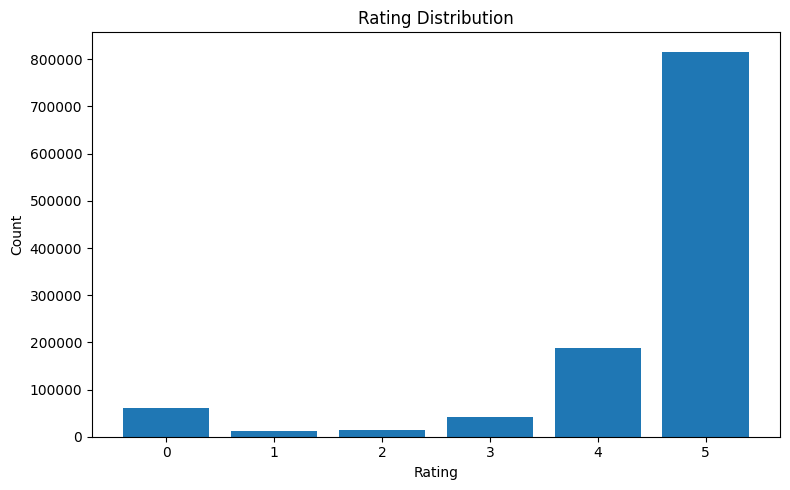

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(rating_distribution["rating"].astype(str), rating_distribution["count"])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [39]:
zero_rating_count = int((interactions["rating"] == 0).sum())
zero_rating_pct = round((zero_rating_count / len(interactions)) * 100, 4)

print("Zero-rating count:", zero_rating_count)
print("Zero-rating percentage:", zero_rating_pct)

Zero-rating count: 60847
Zero-rating percentage: 5.3734




### Observation notes

* The rating distribution is highly imbalanced toward positive feedback.
* Rating `5` is the dominant class with **816,364 observations**, representing **72.09%** of all interactions.
* Rating `4` is the second most common value with **187,360 observations** (**16.55%**).
* Lower ratings are comparatively rare: rating `1` accounts for **1.13%**, rating `2` for **1.25%**, and rating `3` for **3.61%** of interactions.
* Rating `0` appears **60,847 times**, representing **5.37%** of the dataset.
* The presence of rating `0` is important because it may not represent a true explicit preference in the same way as ratings `1` to `5`.
* The distribution indicates a strong positive-feedback bias, which is common in user-generated recommendation datasets where users are more likely to rate items they like.
* Because of this imbalance, models trained directly on the raw ratings may be biased toward predicting high scores.
* A preprocessing decision will be required on whether rating `0` should be excluded from explicit-rating modelling, retained as a distinct class, or transformed into an implicit-feedback signal.
* The skew toward ratings `4` and `5` suggests that evaluation metrics should be interpreted carefully, since naive models may appear strong simply by favouring high predictions.



## 7. Inspect date range
This section parses the interaction date field and measures temporal coverage.

In [40]:
interactions_dates = interactions.copy()
interactions_dates["date_parsed"] = pd.to_datetime(
    interactions_dates["date"],
    errors="coerce",
    dayfirst=True
)

date_summary = {
    "total_rows": int(len(interactions_dates)),
    "parsed_non_null": int(interactions_dates["date_parsed"].notna().sum()),
    "parse_failures": int(interactions_dates["date_parsed"].isna().sum()),
    "min_date": None if interactions_dates["date_parsed"].dropna().empty else interactions_dates["date_parsed"].min().date(),
    "max_date": None if interactions_dates["date_parsed"].dropna().empty else interactions_dates["date_parsed"].max().date(),
}

date_summary_df = pd.DataFrame(
    [{"metric": k, "value": v} for k, v in date_summary.items()]
)
display(date_summary_df)

C:\Users\pippa\AppData\Local\Temp\ipykernel_19448\1508662935.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  interactions_dates["date_parsed"] = pd.to_datetime(


,metric,value
0,total_rows,1132367
1,parsed_non_null,1132367
2,parse_failures,0
3,min_date,2000-01-25
4,max_date,2018-12-20


In [41]:
year_counts = (
    interactions_dates["date_parsed"]
    .dropna()
    .dt.year
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="interaction_count")
)

display(year_counts.head(20))
display(year_counts.tail(20))

,year,interaction_count
0,2000,108
1,2001,2904
2,2002,20922
3,2003,32961
4,2004,45950
5,2005,66643
6,2006,89794
7,2007,141158
8,2008,167295
9,2009,159445


,year,interaction_count
0,2000,108
1,2001,2904
2,2002,20922
3,2003,32961
4,2004,45950
5,2005,66643
6,2006,89794
7,2007,141158
8,2008,167295
9,2009,159445


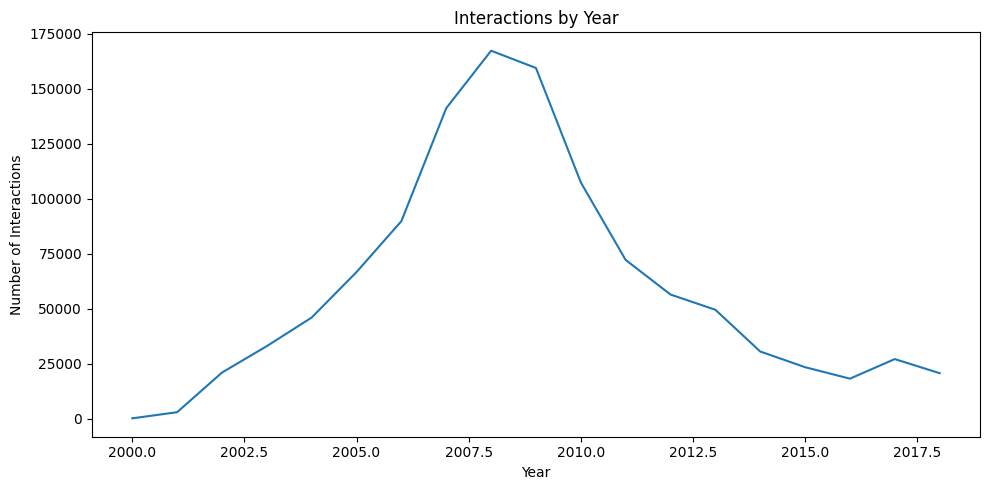

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(year_counts["year"], year_counts["interaction_count"])
plt.title("Interactions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Interactions")
plt.tight_layout()
plt.show()


### Observation notes

* The `date` column was parsed successfully for all **1,132,367** interaction records.
* There were **0 parse failures**, indicating that the date field is consistently formatted and suitable for temporal analysis.
* The interaction data spans from **2000-01-25** to **2018-12-20**, giving a coverage period of almost 19 years.
* This long temporal range is useful for chronological analysis, trend inspection, and time-based train–validation–test splitting.
* Interaction volume increases steadily from 2000 and rises sharply between 2005 and 2008.
* The peak activity occurs in **2008** with **167,295 interactions**, followed by **2009** with **159,445 interactions**.
* After 2009, the number of interactions declines substantially, although the dataset continues to contain observations through 2018.
* The earliest years, especially **2000** and **2001**, contain relatively few records, so they may be less representative for modelling purposes.
* The later years from **2014** onward also contain lower interaction counts compared with the peak period, which may reflect reduced platform activity or incomplete late-period coverage.
* The temporal distribution is clearly non-uniform, so any chronological split should consider that some years are much denser than others.


## 8. Inspect join coverage
This section checks whether recipe IDs in the interactions file are present in the recipe metadata files.

In [43]:
interaction_recipe_ids = set(interactions["recipe_id"].dropna().unique())

raw_recipe_ids = set(raw_recipes["id"].dropna().unique()) if "id" in raw_recipes.columns else set()
pp_recipe_ids = set(pp_recipes["id"].dropna().unique()) if "id" in pp_recipes.columns else set()

matched_raw = interaction_recipe_ids & raw_recipe_ids
matched_pp = interaction_recipe_ids & pp_recipe_ids

join_coverage_df = pd.DataFrame([
    {
        "comparison": "interactions vs raw_recipes",
        "unique_recipe_ids_in_interactions": len(interaction_recipe_ids),
        "unique_recipe_ids_in_recipe_file": len(raw_recipe_ids),
        "matched_ids": len(matched_raw),
        "missing_ids": len(interaction_recipe_ids - raw_recipe_ids),
        "coverage_pct": round((len(matched_raw) / len(interaction_recipe_ids)) * 100, 4),
    },
    {
        "comparison": "interactions vs pp_recipes",
        "unique_recipe_ids_in_interactions": len(interaction_recipe_ids),
        "unique_recipe_ids_in_recipe_file": len(pp_recipe_ids),
        "matched_ids": len(matched_pp),
        "missing_ids": len(interaction_recipe_ids - pp_recipe_ids),
        "coverage_pct": round((len(matched_pp) / len(interaction_recipe_ids)) * 100, 4),
    },
])

display(join_coverage_df)

,comparison,unique_recipe_ids_in_interactions,unique_recipe_ids_in_recipe_file,matched_ids,missing_ids,coverage_pct
0,interactions vs raw_recipes,231637,231637,231637,0,100.0000
1,interactions vs pp_recipes,231637,178265,178265,53372,76.9588


In [44]:
missing_in_raw = sorted(list(interaction_recipe_ids - raw_recipe_ids))[:20]
missing_in_pp = sorted(list(interaction_recipe_ids - pp_recipe_ids))[:20]

print("Sample missing recipe IDs in raw_recipes:", missing_in_raw)
print("Sample missing recipe IDs in pp_recipes:", missing_in_pp)

Sample missing recipe IDs in raw_recipes: []
Sample missing recipe IDs in pp_recipes: [np.int64(39), np.int64(41), np.int64(43), np.int64(48), np.int64(50), np.int64(55), np.int64(67), np.int64(81), np.int64(115), np.int64(118), np.int64(119), np.int64(122), np.int64(133), np.int64(135), np.int64(141), np.int64(144), np.int64(146), np.int64(147), np.int64(148), np.int64(149)]



### Observation notes

* All unique `recipe_id` values present in `interactions` are found in `raw_recipes`.
* The join coverage between `interactions` and `raw_recipes` is **100%**, with **231,637 matched recipe IDs** and **0 missing IDs**.
* This confirms that `raw_recipes` is the complete recipe reference table for the interaction dataset.
* In contrast, the join coverage between `interactions` and `pp_recipes` is **76.96%**.
* Only **178,265** of the **231,637** unique recipe IDs from `interactions` are present in `pp_recipes`.
* This means **53,372 recipe IDs** referenced in the interaction data are missing from the preprocessed recipe table.
* As a result, joining interaction data directly with `pp_recipes` would exclude a substantial portion of recipe entities.
* The missing IDs in `pp_recipes` are not isolated anomalies; they represent a large-scale coverage gap that must be handled explicitly in preprocessing and modelling.
* For maximum data retention, `raw_recipes` should be treated as the primary metadata source.
* `pp_recipes` may still be useful for feature engineering, but its reduced coverage means it cannot serve as the sole recipe table without causing data loss.


## 9. Additional dataset statistics for report and dashboard
These statistics help with the dataset description section and later dashboard pages.

In [45]:
n_users = interactions["user_id"].nunique()
n_items = interactions["recipe_id"].nunique()
n_interactions = len(interactions)

sparsity = 1 - (n_interactions / (n_users * n_items))

dataset_stats = pd.DataFrame([
    {"metric": "n_users", "value": n_users},
    {"metric": "n_items", "value": n_items},
    {"metric": "n_interactions", "value": n_interactions},
    {"metric": "sparsity", "value": sparsity},
])

display(dataset_stats)

,metric,value
0,n_users,2.265700e+05
1,n_items,2.316370e+05
2,n_interactions,1.132367e+06
3,sparsity,9.999784e-01


In [46]:
item_popularity = (
    interactions["recipe_id"]
    .value_counts()
    .rename_axis("recipe_id")
    .reset_index(name="interaction_count")
)

display(item_popularity.head(10))
display(item_popularity["interaction_count"].describe())

,recipe_id,interaction_count
0,2886,1613
1,27208,1601
2,89204,1579
3,39087,1448
4,67256,1322
5,54257,1305
6,22782,1234
7,32204,1220
8,69173,997
9,68955,904


count    231637.000000
mean          4.888541
std          17.532481
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1613.000000
Name: interaction_count, dtype: float64

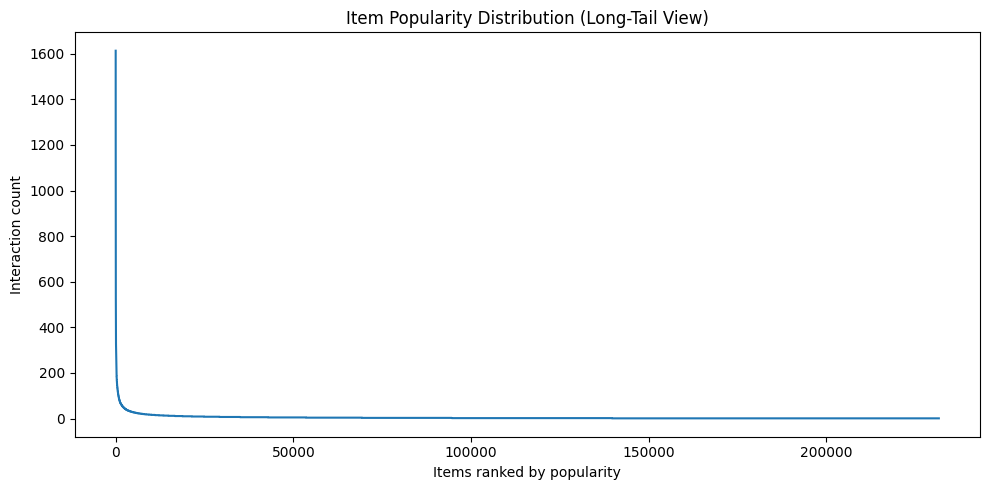

In [47]:
sorted_counts = np.sort(item_popularity["interaction_count"].values)[::-1]

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(sorted_counts) + 1), sorted_counts)
plt.title("Item Popularity Distribution (Long-Tail View)")
plt.xlabel("Items ranked by popularity")
plt.ylabel("Interaction count")
plt.tight_layout()
plt.show()

In [48]:
user_activity = (
    interactions["user_id"]
    .value_counts()
    .rename_axis("user_id")
    .reset_index(name="interaction_count")
)

display(user_activity.head(10))
display(user_activity["interaction_count"].describe())

,user_id,interaction_count
0,424680,7671
1,37449,5603
2,383346,4628
3,169430,4076
4,128473,3917
5,89831,3353
6,58104,3288
7,133174,3107
8,199848,3018
9,305531,2902


count    226570.000000
mean          4.997868
std          49.663111
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        7671.000000
Name: interaction_count, dtype: float64

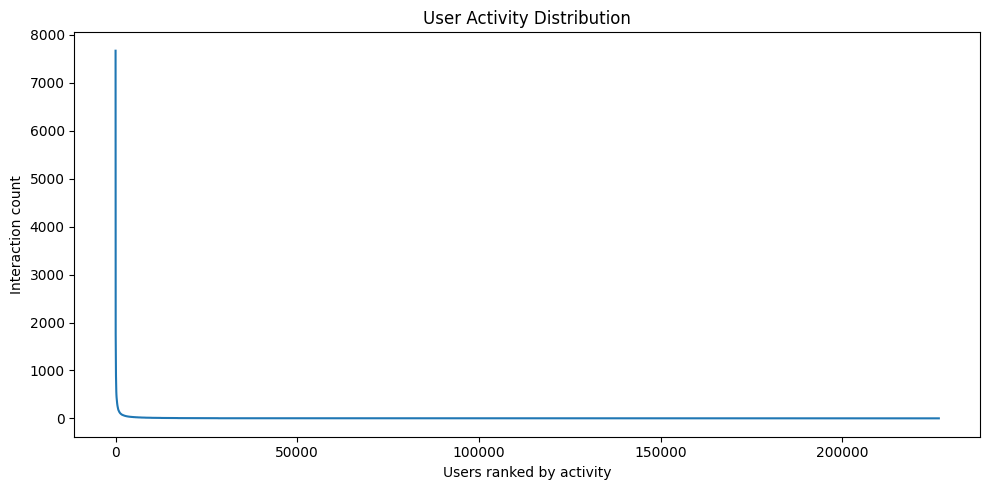

In [49]:
sorted_user_counts = np.sort(user_activity["interaction_count"].values)[::-1]

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(sorted_user_counts) + 1), sorted_user_counts)
plt.title("User Activity Distribution")
plt.xlabel("Users ranked by activity")
plt.ylabel("Interaction count")
plt.tight_layout()
plt.show()


### Observation notes

* The interaction matrix is extremely sparse, with **226,570 users**, **231,637 items**, and **1,132,367 observed interactions**.
* The estimated sparsity is approximately **0.9999784**, meaning that only a very small fraction of all possible user–item pairs are observed.
* This level of sparsity is typical of large recommender system datasets and supports the use of recommendation methods designed for sparse interaction matrices, such as collaborative filtering and matrix factorisation.
* Item popularity follows a clear **long-tail distribution**.
* Although a small number of recipes are highly popular, most recipes receive very few interactions.
* The median number of interactions per item is **2**, while the mean is **4.89**, showing that the distribution is strongly right-skewed.
* The most popular recipe has **1,613 interactions**, but the lower quartile and median values indicate that a large proportion of recipes appear only once or twice.
* User activity is also highly uneven and exhibits a long-tail pattern.
* The median number of interactions per user is **1**, while the mean is **5.00**, indicating that most users interact with very few recipes.
* The most active user has **7,671 interactions**, which is far above the typical user activity level.
* The lower quartile of user activity is **1**, and the upper quartile is only **2**, meaning that at least 75% of users have interacted with no more than two recipes.
* These results indicate a strong **cold-start and low-support problem**, particularly for inactive users and unpopular recipes.
* Because both user activity and item popularity are heavily skewed, later preprocessing may need to apply minimum-interaction thresholds for certain models, especially neighbourhood-based collaborative filtering methods.
* At the same time, aggressive filtering would reduce dataset size, so there is a trade-off between model robustness and data retention that should be justified explicitly.




## 11. Summary

The dataset is suitable for large-scale recipe recommendation experiments and provides a strong foundation for subsequent preprocessing, modelling, and evaluation. The three source files play distinct roles within the project. The `interactions` table is the core behavioural dataset, containing user IDs, recipe IDs, dates, ratings, and review text. The `raw_recipes` table appears to be the main recipe metadata source and fully covers all recipe IDs referenced in the interaction data. The `pp_recipes` table appears to contain preprocessed recipe attributes, but it covers only a subset of the full recipe catalogue and therefore cannot be used as the sole recipe reference file without causing data loss.

In terms of data quality, the interaction dataset is structurally very complete. Missing data is minimal, with only 169 missing values in the `review` column, representing a negligible proportion of the full dataset. All essential modelling fields, including `user_id`, `recipe_id`, `date`, and `rating`, are complete and therefore suitable for downstream recommendation tasks. Duplicate analysis also showed strong consistency. No full-row duplicates were found in any of the three datasets, and no duplicate user–recipe pairs were found in the interaction table. Recipe identifiers are unique in both recipe files, although recipe names are not unique in `raw_recipes`, meaning that all joins and entity matching should rely on `recipe_id` rather than title.

The rating structure is highly imbalanced and strongly skewed toward positive feedback. Ratings 4 and 5 dominate the dataset, with rating 5 alone accounting for over 72% of all interactions. Lower ratings are comparatively rare, and a non-standard rating value of 0 is also present in about 5.37% of observations. This indicates that the project must make an explicit preprocessing decision regarding how zero ratings will be treated. For explicit-rating models, it may be more appropriate to use only ratings 1–5, while rating 0 may be better handled separately or considered as part of an implicit-feedback representation. The positive skew also suggests that evaluation results must be interpreted carefully, since naive models may perform well simply by favouring high predicted scores.

Temporal analysis confirmed that the dataset supports chronological experimentation. All dates were parsed successfully, with no failures, and the interaction history spans from January 2000 to December 2018. This makes time-aware splitting feasible for training, validation, and testing. However, the yearly interaction volume is not evenly distributed. Activity rises gradually, peaks around 2008–2009, and then declines in later years. This non-uniform temporal density should be considered when defining chronological splits, since some time periods are much more information-rich than others.

Join-coverage analysis produced one of the most important findings. The interaction dataset has complete recipe-ID coverage against `raw_recipes`, confirming that `raw_recipes` is the correct master reference table. By contrast, only 76.96% of unique interaction recipe IDs are found in `pp_recipes`, leaving 53,372 recipe IDs unmatched. This means that direct reliance on `pp_recipes` would exclude a substantial part of the recipe space and reduce the number of usable interactions. Therefore, the raw recipe table should remain the primary metadata source, while the preprocessed recipe table should be used selectively for feature engineering where appropriate.

Finally, the dataset exhibits the structural characteristics of a realistic recommender system problem. The user–item matrix is extremely sparse, with over 226,000 users, over 231,000 items, and just over 1.13 million observed interactions, producing a sparsity level of approximately 0.9999784. Both item popularity and user activity follow strong long-tail distributions. Most items receive very few interactions, and most users interact with only one or two recipes, while a small minority of items and users are extremely active. This confirms the presence of sparsity, popularity bias, and cold-start challenges. These findings strongly support the planned comparative model set, including a popularity baseline, collaborative filtering, and matrix factorisation methods such as SVD. They also justify considering filtering thresholds or hybrid enhancements later, although such choices will need to balance model robustness against retention of the available data.

Overall, the observations show that the dataset is usable, sufficiently large, and methodologically appropriate for recommendation research. The main issues identified are not critical data-quality failures, but rather modelling considerations: highly imbalanced ratings, the ambiguous meaning of rating 0, incomplete coverage in the preprocessed recipe file, extreme sparsity, and long-tail behaviour. 
